# 第075课 真实执行实验

隐变量：比较分布、坐标、子空间与语义，不把重构等同于唯一机制。

本Notebook读取经摘要核验的原创CSV，真正执行算法；冻结输出便于离线阅读。建议重启内核后Run All。

In [1]:
import numpy as np  # 数组运算库。
from common import load_data  # 同时核验摘要和生成器字节。
data = load_data()  # 读取本讲数据，不访问网络。
print({name: len(rows['id']) for name, rows in data.items()})  # 核对对象数量。

{'train': 600, 'audit': 300, 'hetero_train': 600, 'hetero_audit': 300}


## 先预测，再算小例子

请先在纸上写出预期，再执行下一格；讲义和答案册解释每项。

In [2]:
from latent import ppca, posterior  # 闭式估计与条件均值分开。
from experiment import matrix  # 只取观测x列。
mu, W, noise, values, directions = ppca(matrix(data['train']), 2)  # 二维潜模型。
print(W, noise, values)  # 核对形状、载荷和被舍弃方向的平均方差。

[[-1.11659771 -0.85478882]
 [-1.08708083  0.06828206]
 [ 0.52267918 -1.06214365]
 [ 1.00535271 -0.32333602]] 0.06484804321542675 [3.77731081 2.03286974 0.06917058 0.06052551]


## 执行完整冻结协议

下面调用run重新计算所有结果，未直接用冻结JSON充当实验输出。

In [3]:
from experiment import run  # 导入本讲完整实验。
report = run()  # 实际执行拟合、对照与评价。
print({k: v for k, v in report.items() if 'difference' in k or 'mse' in k})
print(report['heteroscedastic'])

{'covariance_max_difference': 4.440892098500626e-16, 'rotation_reconstruction_max_difference': 1.3322676295501878e-15, 'rotation_log_density_max_difference': 1.2434497875801753e-14, 'score_rotation_max_difference': 1.3322676295501878e-15, 'raw_factor_mse': 4.123552277721147, 'aligned_factor_mse': 0.023810311056359203, 'pca_reconstruction_mse': 0.031041243213139336, 'ppca_signal_reconstruction_mse': 0.03193182955526829, 'scale_covariance_max_difference': 0.0}
{'ppca_audit_mean_log_density': -6.369453384550755, 'fa_audit_mean_log_density': -6.063902632163139, 'fa_noise': [0.22920177704440214, 0.12011651900082954, 0.4405232724060135, 1.478339371829888], 'ppca_noise': 0.5839442670183171, 'fa_iterations': 100}


## 保存本次重算结果并核对性质

显式测试含独立实现、数学恒等式和必要边界，错误会抛出异常。

In [4]:
from common import write_json  # 保存便于追查的本次结果。
write_json('outputs/notebook/result.json', report)  # 不覆盖公开冻结报告。
import subprocess, sys  # 新进程运行显式测试。
completed = subprocess.run([sys.executable, 'test_experiment.py', '--report', 'outputs/notebook/result.json', '--out', 'outputs/notebook/tests.json'], check=True, capture_output=True, text=True)
print('本次Notebook重算结果已通过显式测试。')

本次Notebook重算结果已通过显式测试。


## 重新绘图并内嵌

图从本次重算报告与原创数据生成。中文图题及每个坐标含义见讲义对应段落。

01_loadings.png


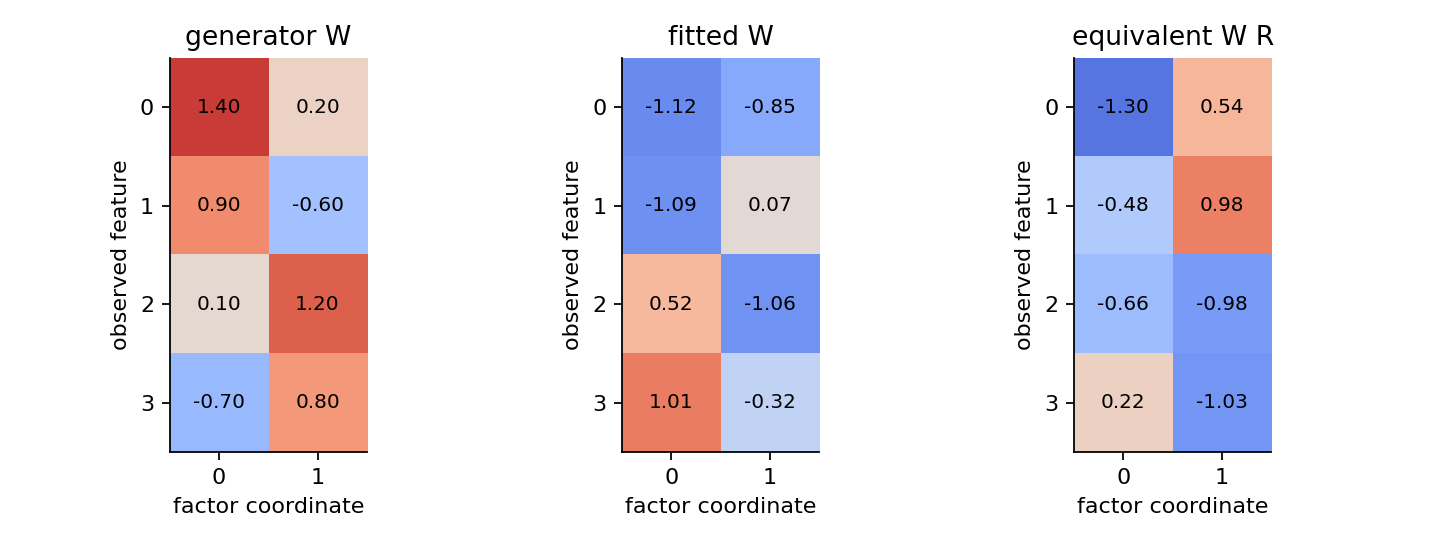

02_rotation.png


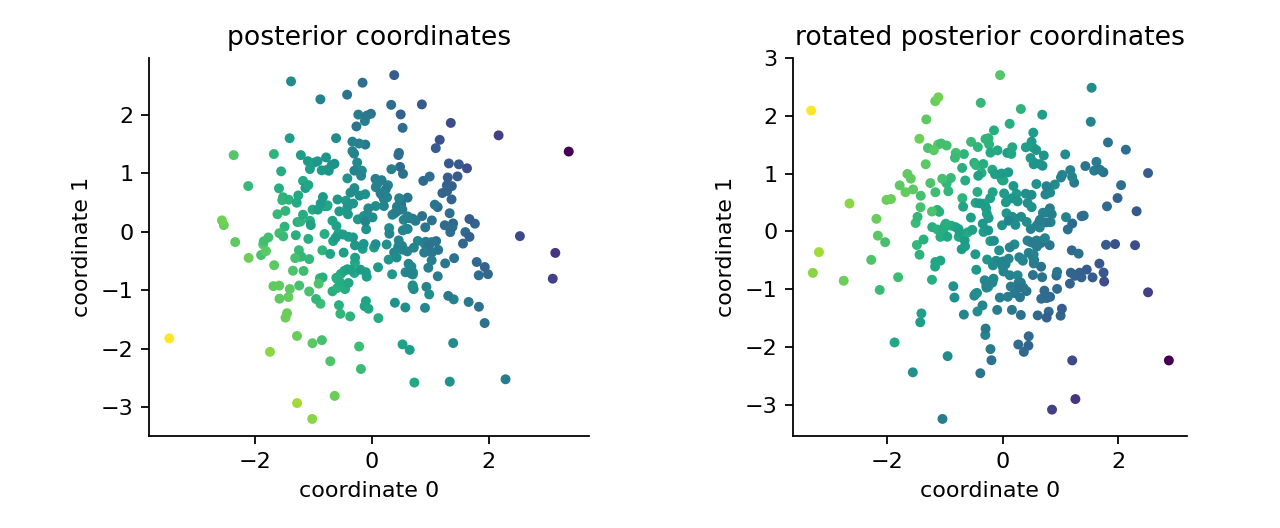

03_spectrum.png


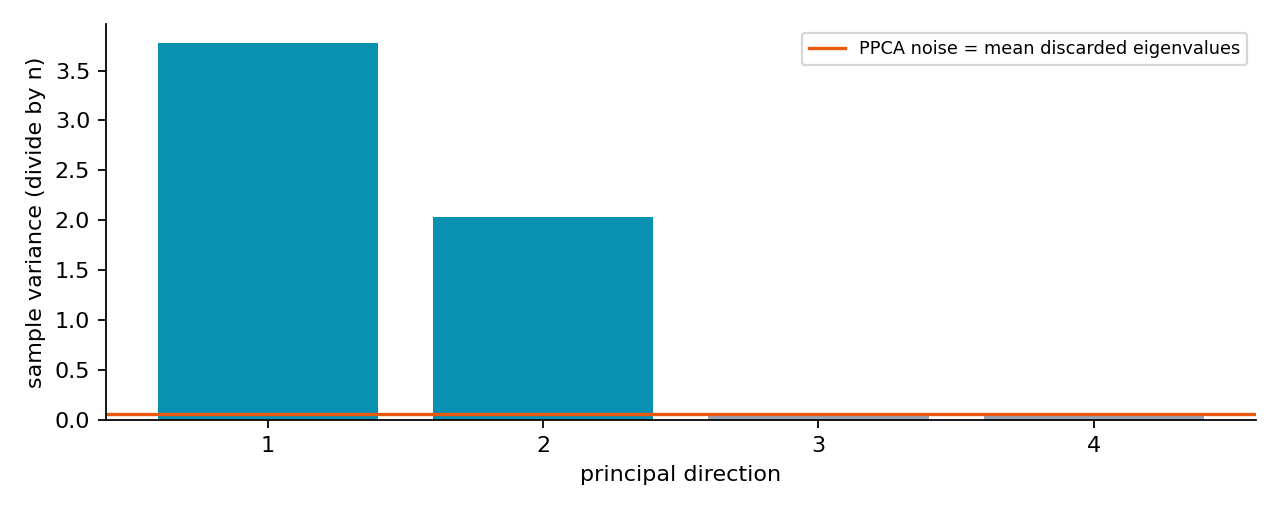

04_validation.png


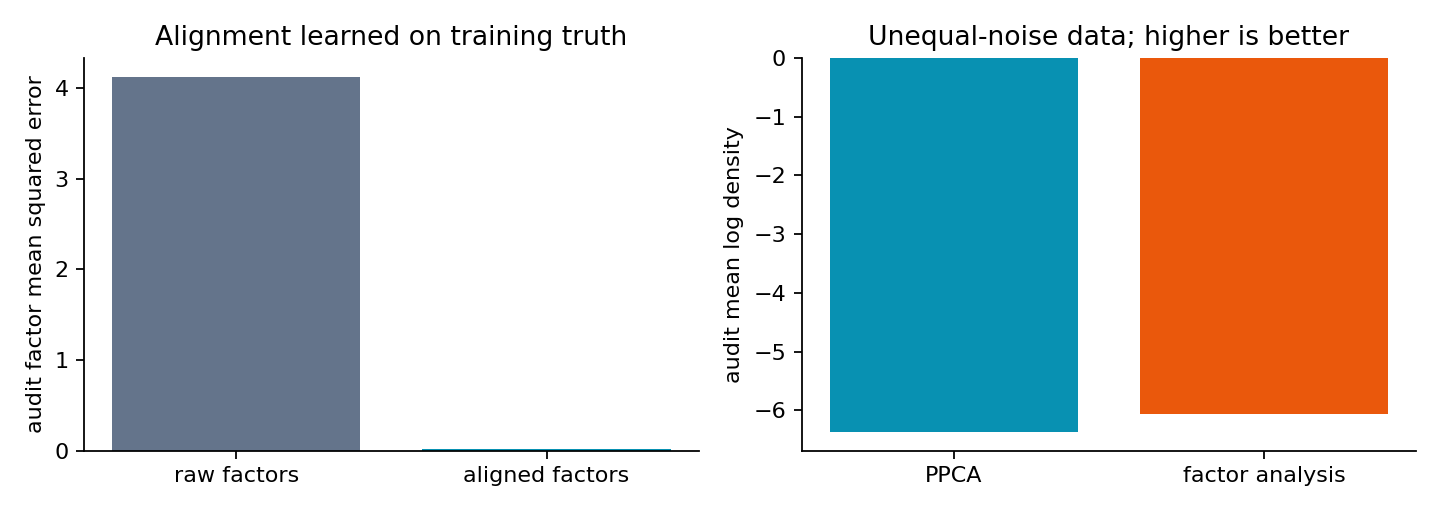

In [5]:
subprocess.run([sys.executable, 'plots.py', '--report', 'outputs/notebook/result.json', '--directory', 'outputs/notebook/figures'], check=True, capture_output=True, text=True)  # 独立绘图进程。
from pathlib import Path  # 枚举生成图。
from IPython.display import display, Image  # 嵌入PNG，不依赖外部链接。
for path in sorted(Path('outputs/notebook/figures').glob('*.png')):
    print(path.name)  # 文件名帮助对应讲义图题。
    display(Image(filename=str(path)))  # 图像数据保存在执行输出内。

## 写下你的边界声明

用一句话说明本实验已支持什么，再用一句话说明尚不能据此推出什么。请对照独立答案册，而不是只写“测试通过”。

执行验证不包含Jupyter浏览器界面和外部socket内核传输；本Notebook采用新Python进程中的真实IPython计算内核。